/var/folders/sx/1b55yzdj67g8dg8fyg5xygx00000gn/T/ipykernel_2589/1038474086.py:185: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.errorbar(dBydx_dBxdy_notnan,dBydx_dBxdy_notnan, fmt='ro',c='Gray',label=r'B$_{pos}$', alpha=plt_alpha, markersize=marker_size)
/var/folders/sx/1b55yzdj67g8dg8fyg5xygx00000gn/T/ipykernel_2589/1038474086.py:186: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.errorbar(dBydx_dBxdy_notnan_f1,dBydx_dBxdy_notnan_f1, fmt='ro',c='Gray', alpha=plt_alpha, markersize=marker_size)
/var/folders/sx/1b55yzdj67g8dg8fyg5xygx00000gn/T/ipykernel_2589/1038474086.py:187: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.errorbar(dBydx_dBxdy_

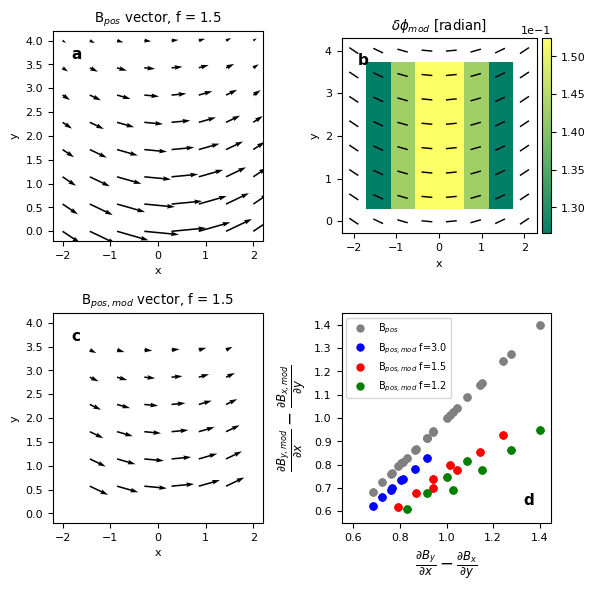

In [8]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from astropy.io import fits
import matplotlib.cm as cm
import matplotlib.patches as patches
import matplotlib as mpl
from uncertainties import ufloat
from uncertainties.umath import *
from uncertainties import unumpy
from mpl_toolkits.axes_grid1 import make_axes_locatable

font = {'size'   : 8}
mpl.rc('font', **font)
minorLocator = MultipleLocator(10)

# define grid
nx, ny = 8, 8
#x = np.linspace(-50, 50, nx)
#y = np.linspace(0, 100, ny)
#x = np.linspace(-8, 8, nx)
#y = np.linspace(0, 16, ny)
scale_factor=1
x = np.linspace(-2/scale_factor, 2/scale_factor, nx)
y = np.linspace(0, 4/scale_factor, ny)

# create 2D mesh
X, Y = np.meshgrid(x, y, indexing='xy')

Bx0 = 1*X/X #np.abs(X) #0.5*X/X #(-Bx0 * (Y+1) * (51-np.abs(X))/50)/100
By0 = 1.0  # change as needed
rmax = 2.5/scale_factor
Ymax = 5/scale_factor

f1 = 3
f2 = 1.2
f = 1.5

#############
By0 = Bx0*2*X/(4*f1)
Bpos = np.sqrt(Bx0**2+By0**2)
Bx =  Bx0/Bpos*np.sqrt(rmax**2 - X**2)/rmax*(Ymax-Y)
By = By0/Bpos*np.sqrt(rmax**2 - X**2)/rmax*(Ymax-Y)

dBydy, dBydx = np.gradient(By)
dBxdy, dBxdx = np.gradient(Bx)

PA = np.arctan(By/Bx)
PA_x = np.cos(PA)
PA_y = np.sin(PA)

PA_std = np.full(shape=(len(PA),len(PA[0])), fill_value=np.nan)
for xx in range(1, len(PA[0])-1):
    for yy in range(1, len(PA)-1):
        data =  PA[yy-1:yy+2,xx-1:xx+2]
        PA_average = np.average(data)
        PA_variance = np.average((data - PA_average)**2)
        PA_std[yy,xx] = np.sqrt(PA_variance)

PA_std_sn = 1/6 #assume SN=3 pol detection, PA_std_sn = 1/2/SN see Eq. 20 in Hull & Plambeck 2015 "The 1.3mm Full-Stokes Polarization System at CARMA"
Bx_mod = Bx*PA_std_sn/np.sqrt(PA_std_sn**2+PA_std**2)
By_mod = By*PA_std_sn/np.sqrt(PA_std_sn**2+PA_std**2)

dBydy_mod, dBydx_mod = np.gradient(By_mod)
dBxdy_mod, dBxdx_mod = np.gradient(Bx_mod)
dBydx_dBxdy = (dBydx - dBxdy).flatten()
dBydx_dBxdy_mod = (dBydx_mod - dBxdy_mod).flatten()
dBydx_dBxdy_notnan_f1 = dBydx_dBxdy[~np.isnan(dBydx_dBxdy_mod)]
dBydx_dBxdy_mod_notnan_f1 = dBydx_dBxdy_mod[~np.isnan(dBydx_dBxdy_mod)]
dBydx_dBxdy_f1 = dBydx_dBxdy

#############
By0 = Bx0*2*X/(4*f2)
Bpos = np.sqrt(Bx0**2+By0**2)
Bx =  Bx0/Bpos*np.sqrt(rmax**2 - X**2)/rmax*(Ymax-Y)
By = By0/Bpos*np.sqrt(rmax**2 - X**2)/rmax*(Ymax-Y)

dBydy, dBydx = np.gradient(By)
dBxdy, dBxdx = np.gradient(Bx)

PA = np.arctan(By/Bx)
PA_x = np.cos(PA)
PA_y = np.sin(PA)

PA_std = np.full(shape=(len(PA),len(PA[0])), fill_value=np.nan)
for xx in range(1, len(PA[0])-1):
    for yy in range(1, len(PA)-1):
        data =  PA[yy-1:yy+2,xx-1:xx+2]
        PA_average = np.average(data)
        PA_variance = np.average((data - PA_average)**2)
        PA_std[yy,xx] = np.sqrt(PA_variance)

PA_std_sn = 1/6 #assume SN=3 pol detection, PA_std_sn = 1/2/SN see Eq. 20 in Hull & Plambeck 2015 "The 1.3mm Full-Stokes Polarization System at CARMA"
Bx_mod = Bx*PA_std_sn/np.sqrt(PA_std_sn**2+PA_std**2)
By_mod = By*PA_std_sn/np.sqrt(PA_std_sn**2+PA_std**2)

dBydy_mod, dBydx_mod = np.gradient(By_mod)
dBxdy_mod, dBxdx_mod = np.gradient(Bx_mod)
dBydx_dBxdy = (dBydx - dBxdy).flatten()
dBydx_dBxdy_mod = (dBydx_mod - dBxdy_mod).flatten()
dBydx_dBxdy_notnan_f2 = dBydx_dBxdy[~np.isnan(dBydx_dBxdy_mod)]
dBydx_dBxdy_mod_notnan_f2 = dBydx_dBxdy_mod[~np.isnan(dBydx_dBxdy_mod)]
dBydx_dBxdy_f2 = dBydx_dBxdy

####3rd####
By0 = Bx0*2*X/(4*f3)
Bpos = np.sqrt(Bx0**2+By0**2)
Bx =  Bx0/Bpos*np.sqrt(rmax**2 - X**2)/rmax*(Ymax-Y)
By = By0/Bpos*np.sqrt(rmax**2 - X**2)/rmax*(Ymax-Y)

dBydy, dBydx = np.gradient(By)
dBxdy, dBxdx = np.gradient(Bx)
cmp0=cm.summer

PA = np.arctan(By/Bx)
PA_x = np.cos(PA)
PA_y = np.sin(PA)

PA_std = np.full(shape=(len(PA),len(PA[0])), fill_value=np.nan)
#PA_std = np.zeros([len(PA),len(PA[0])]) 
#print(PA_std)
for xx in range(1, len(PA[0])-1):
    for yy in range(1, len(PA)-1):
        #print(xx,yy)
        data =  PA[yy-1:yy+2,xx-1:xx+2]
        #print(data)
        PA_average = np.average(data)
        PA_variance = np.average((data - PA_average)**2)
        PA_std[yy,xx] = np.sqrt(PA_variance)

PA_std_sn = 1/6 #assume SN=3 pol detection, PA_std_sn = 1/2/SN see Eq. 20 in Hull & Plambeck 2015 "The 1.3mm Full-Stokes Polarization System at CARMA"
Bx_mod = Bx*PA_std_sn/np.sqrt(PA_std_sn**2+PA_std**2)
By_mod = By*PA_std_sn/np.sqrt(PA_std_sn**2+PA_std**2)

dBydy_mod, dBydx_mod = np.gradient(By_mod)
dBxdy_mod, dBxdx_mod = np.gradient(Bx_mod)
dBydx_dBxdy = (dBydx - dBxdy).flatten()
dBydx_dBxdy_mod = (dBydx_mod - dBxdy_mod).flatten()
dBydx_dBxdy_notnan = dBydx_dBxdy[~np.isnan(dBydx_dBxdy_mod)]
dBydx_dBxdy_mod_notnan = dBydx_dBxdy_mod[~np.isnan(dBydx_dBxdy_mod)]

import matplotlib.pyplot as plt
fig = plt.figure(figsize=(6,6), layout='tight')
extent0=[-2/scale_factor-(x[1]-x[0])/2, 2/scale_factor+(x[1]-x[0])/2, 0-(y[1]-y[0])/2, 4/scale_factor+(y[1]-y[0])/2]

sc = 30 #scale for quiver

ax = plt.subplot(2,2,1)
plt.title(r'B$_{pos}$ vector, f = 1.5')
plt.xlabel('x')
plt.ylabel('y')
ax.set(aspect=1)
ax.quiver(X, Y, Bx, By, scale=sc)
ax.text(0.11,0.89, r'a',horizontalalignment='center',verticalalignment='center',transform=ax.transAxes, fontsize=11, weight='bold')

ax = plt.subplot(2,2,2)
plt.title(r'$\delta\phi_{mod}$ [radian]')
plt.xlabel('x')
plt.ylabel('y')
ax.set(aspect=1)
cs = ax.imshow(PA_std, interpolation='nearest', cmap=cmp0, extent=extent0, origin='lower')
ax.quiver(X, Y, PA_x, PA_y, headwidth=0, headlength=0, headaxislength=0, pivot='mid',edgecolor='none')
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(cs,cax=cax)
cbar.formatter.set_powerlimits((0, 0))
cbar.update_ticks()
ax.text(0.11,0.89, r'b',horizontalalignment='center',verticalalignment='center',transform=ax.transAxes, fontsize=11, weight='bold')

ax = plt.subplot(2,2,3)
plt.title(r'B$_{pos,mod}$ vector, f = 1.5')
plt.xlabel('x')
plt.ylabel('y')
ax.set(aspect=1)
ax.quiver(X, Y, Bx_mod, By_mod, scale=sc)
ax.text(0.11,0.89, r'c',horizontalalignment='center',verticalalignment='center',transform=ax.transAxes, fontsize=11, weight='bold')

ax = plt.subplot(2,2,4)
ax.set(aspect=1)
plt_alpha = 1.0
marker_size = 5
plt.errorbar(dBydx_dBxdy_notnan,dBydx_dBxdy_notnan, fmt='ro',c='Gray',label=r'B$_{pos}$', alpha=plt_alpha, markersize=marker_size)
plt.errorbar(dBydx_dBxdy_notnan_f1,dBydx_dBxdy_notnan_f1, fmt='ro',c='Gray', alpha=plt_alpha, markersize=marker_size)
plt.errorbar(dBydx_dBxdy_notnan_f2,dBydx_dBxdy_notnan_f2, fmt='ro',c='Gray', alpha=plt_alpha, markersize=marker_size)
#plt.errorbar(dBydx_dBxdy_notnan_f1,dBydx_dBxdy_mod_notnan_f1, fmt='go',label=f'f={f1}', alpha=plt_alpha, markersize=marker_size)
#plt.errorbar(dBydx_dBxdy_notnan,dBydx_dBxdy_mod_notnan, fmt='ro',label=f'f={f3}', alpha=plt_alpha, markersize=marker_size)
#plt.errorbar(dBydx_dBxdy_notnan_f2,dBydx_dBxdy_mod_notnan_f2, fmt='bo',label=f'f={f2}', alpha=plt_alpha, markersize=marker_size)
plt.errorbar(dBydx_dBxdy_notnan_f1,dBydx_dBxdy_mod_notnan_f1, fmt='bo',label=r'B$_{pos,mod}$ f=3.0', alpha=plt_alpha, markersize=marker_size)
plt.errorbar(dBydx_dBxdy_notnan,dBydx_dBxdy_mod_notnan, fmt='ro',label=r'B$_{pos,mod}$ f=1.5', alpha=plt_alpha, markersize=marker_size)
plt.errorbar(dBydx_dBxdy_notnan_f2,dBydx_dBxdy_mod_notnan_f2, fmt='go',label=r'B$_{pos,mod}$ f=1.2', alpha=plt_alpha, markersize=marker_size)
plt.xlabel(r'$\frac{\partial B_y}{\partial x}-\frac{\partial B_x}{\partial y}$', fontsize=12)
plt.ylabel(r'$\frac{\partial B_{y,mod}}{\partial x}-\frac{\partial B_{x,mod}}{\partial y}$', fontsize=12)
plt.legend(frameon=True, fontsize=7)
ax.text(0.89,0.11, r'd',horizontalalignment='center',verticalalignment='center',transform=ax.transAxes, fontsize=11, weight='bold')
plt.xlim(0.55,1.45)
plt.ylim(0.55,1.45)

#plt.show()
plt.savefig('sim_delta_phi_4panels4.pdf')